In [1]:
!pip install transformers torch pandas matplotlib

In [2]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

print("Model Loaded Successfully!")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Model Loaded Successfully!


In [3]:
review = "This product is amazing and works perfectly."

result = classifier(review)

print(result)


[{'label': 'POSITIVE', 'score': 0.999881386756897}]


In [7]:
review = input("Enter a review: ")

result = classifier(review)

print("\nSentiment:", result[0]['label'])
print("Confidence Score:", round(result[0]['score'], 4))

Enter a review: I love this product

Sentiment: POSITIVE
Confidence Score: 0.9999


In [8]:
import pandas as pd

reviews = [
    "This product is amazing.",
    "I hate this service.",
    "The experience was average.",
    "Very good quality.",
    "Worst purchase ever."
]

results = []

for review in reviews:
    sentiment = classifier(review)[0]

    results.append([
        review,
        sentiment['label'],
        round(sentiment['score'], 4)
    ])

df = pd.DataFrame(
    results,
    columns=["Review", "Sentiment", "Confidence"]
)

df

,Review,Sentiment,Confidence
0,This product is amazing.,POSITIVE,0.9999
1,I hate this service.,NEGATIVE,0.9997
2,The experience was average.,NEGATIVE,0.9260
3,Very good quality.,POSITIVE,0.9999
4,Worst purchase ever.,NEGATIVE,0.9998


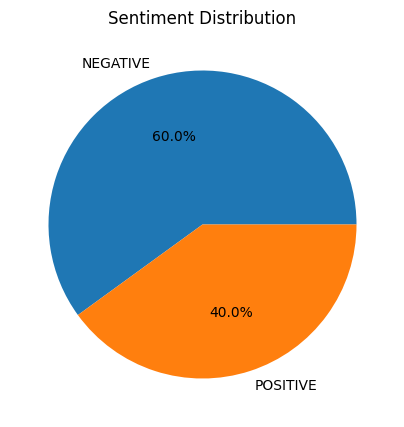

In [9]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution")
plt.show()

In [10]:
# Save results to CSV

df.to_csv("sentiment_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [12]:
from google.colab import files

files.download("sentiment_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>